# Comparison between: Rule-based vs ECMS vs DP

Same lap (Canada 2026 quali), same $SoC(0)=0.9$, same $E_{ES2K}(0)=0$.
Main Object: quantify how close rule-based approaches and ECMS come to the theoretical optimum calculated by DP.

- **Rule-based**: `controller/rule_based_controller.py` + `plant/powertrain.py` (the true, complete Willans model, 
not the approximation used by DP/ECMS).
- **ECMS**: same quadratic cost, for `s(k)` a proportional feedback in the trajectory of the SoC of DP.
- **DP**:results calculated and saved in the directory data

In [1]:
import numpy as np
import matplotlib.pyplot as plot
from plant.parameters import params
from plant.battery import battery_step, coef_quad, Uoc, thermal_model
from plant.powertrain import powertrain
from controller.rule_based_controller import rule_based_split


In [2]:
Delta_t = 0.1

Voc = params['V_oc_nom']
Q_bat = params['E_pack_capacity'] / Voc

P_MGU_max = params['P_MGU_max']
P_MGU_min = params['P_MGU_min']
eta_MGU = params['eta_MGU']
P_eng_max = params['P_ICE_max']
E_ES2K_max = params['E_deploy_max']
SOC_min = params['SoC_min']
SOC_max = params['SoC_max']

eta_ICE = params['eta_ICE']
P_ICE0 = params['P_ICE0']
LHV = params['LHV']
m_dot_max = params['m_dot_max'] / 3600.0

Tbat = params['T_bat_init']

DATA_DIR = '/app/data/qualifying_Canada'

# Same lap for all three methods
data = np.load(f'/app/data/qualifying_Canada/Canada_qualifying.npy')
t, v, a = data[0,:], data[1,:], data[2,:]

data_of_power_gb = np.load(f'{DATA_DIR}/power_domand_quali.npy')
P_gb = data_of_power_gb[1,:]

N = len(t)

SOC_0 = 0.9
E_0 = 0.0


## 1.Load the DP results (already calculated)

In [3]:
SoC_dp = np.load(f'data/qualifying_Canada/SOC_DP_Canada_qualifying.npy')
P_MGUK_dp = np.load(f'data/qualifying_Canada/P_MGUK_DP_Canada_qualifying.npy')
J_dp = np.load(f'data/qualifying_Canada/J_DP_Canada_qualifying.npy')
E_ES2K_dp = np.load(f'data/qualifying_Canada/E_ES2K_DP_Canada_qualifying.npy')
shortfall_dp = np.load(f'data/qualifying_Canada/shortfall_DP_Canada_qualifying.npy')

fuel_dp = np.sum(J_dp) * 1e3  # g
print(f"fuel: {fuel_dp:.2f} g | final SoC: {SoC_dp[-2]:.4f} | deploy: {E_ES2K_dp[-2]/1e6:.3f} MJ")


fuel: 813.03 g | final SoC: 0.2000 | deploy: 8.019 MJ


## 2. Run a rule-based simulation on the same cycle.

Use `plant/powertrain.py` directly (full Willans line, not 
the DP/ECMS bound approximation) to remain faithful to the 
model the rule-based controller was designed to drive from the start.

In [4]:
def simulate_rule_based(SOC_0, E_0, P_gb, dt=Delta_t):
    N_local = len(P_gb)

    SoC_sim = np.zeros(N_local)
    E_ES2K_sim = np.zeros(N_local)
    E_recharge_sim = np.zeros(N_local)
    P_MGUK_sim = np.zeros(N_local)
    P_ICE_sim = np.zeros(N_local)
    m_dot_sim = np.zeros(N_local)
    J_sim = np.zeros(N_local)
    shortfall_sim = np.zeros(N_local)
    Tbat_sim = np.zeros(N)

    SoC_sim[0] = SOC_0
    E_ES2K_sim[0] = E_0
    Tbat_sim[0]=params['T_bat_init']

    for k in range(N_local - 1):
        u_split = rule_based_split(SoC_sim[k], P_gb[k], E_ES2K_sim[k], params)

        P_ICE_sim[k], P_MGUK_sim[k], P_mech_MGUK_real, shortfall, E_deploy_next, E_recharge_next,m_dot_sim[k] = powertrain(
            P_gb[k], u_split, E_ES2K_sim[k], E_recharge_sim[k], params, dt
        )

        shortfall_sim[k] = max(shortfall, 0.0)  # negative shortfall in braking = brake-absorbed, not a real gap

        J_sim[k] = m_dot_sim[k] * dt

        SoC_sim[k+1], _, I2_k = battery_step(SoC_sim[k],  P_MGUK_sim[k], coef_quad, Tbat_sim[k], params, dt)
        Tbat_sim[k+1] = thermal_model(I2_k, Tbat_sim[k], params, dt)
        E_ES2K_sim[k+1] = E_deploy_next
        E_recharge_sim[k+1] = E_recharge_next

    return P_MGUK_sim, P_ICE_sim, m_dot_sim, J_sim, SoC_sim, E_ES2K_sim, shortfall_sim


P_MGUK_rb, P_eng_rb, m_dot_rb, J_rb, SoC_rb, E_ES2K_rb, shortfall_rb = simulate_rule_based(SOC_0, E_0, P_gb)

fuel_rb = np.sum(J_rb) * 1e3
print(f"Rule-based -- fuel: {fuel_rb:.2f} g | final SoC: {SoC_rb[-2]:.4f} | deploy: {E_ES2K_rb[-2]/1e6:.3f} MJ")


Rule-based -- fuel: 773.50 g | final SoC: 0.5417 | deploy: 6.108 MJ


## 3. Simulate ECMS on the same lap.

Same functions already validated in `controller/02_ECMS.ipynb`.

In [5]:
d = np.load('data/qualifying_Canada/ECMS_Canada_qualifying.npz')
SoC_ecms, J_ecms          = d['SoC'], d['J']
E_ES2K_ecms, sf_ecms      = d['E_ES2K'], d['shortfall']
P_MGUK_ecms, P_eng_ecms   = d['P_MGUK'], d['P_eng']
P_mech_MGUK_ecms          = d['P_mech_MGUK']
fuel_ecms = np.sum(J_ecms) * 1e3
print(f"ECMS -- fuel: {fuel_ecms:.2f} g | final SoC: {SoC_ecms[-2]:.4f} | deploy: {E_ES2K_ecms[-2]/1e6:.3f} MJ")

ECMS -- fuel: 820.09 g | final SoC: 0.2046 | deploy: 8.163 MJ


## 4. Summary table

In [6]:
sf_dp_MJ   = np.sum(shortfall_dp) * Delta_t / 1e6
sf_ecms_MJ = np.sum(sf_ecms)      * Delta_t / 1e6
sf_rb_MJ   = np.sum(shortfall_rb) * Delta_t / 1e6

print(f"{'Method':<28}{'Fuel [g]':>11}{'SoC fin':>10}{'Deploy [MJ]':>13}{'Shortfall [MJ]':>16}")
print("-" * 78)
print(f"{'DP (full future knowledge)':<28}{fuel_dp:>11.2f}{SoC_dp[-2]:>10.4f}{E_ES2K_dp[-2]/1e6:>13.3f}{sf_dp_MJ:>16.3f}")
print(f"{'ECMS (DP-referenced)':<28}{fuel_ecms:>11.2f}{SoC_ecms[-2]:>10.4f}{E_ES2K_ecms[-2]/1e6:>13.3f}{sf_ecms_MJ:>16.3f}")
print(f"{'Rule-based':<28}{fuel_rb:>11.2f}{SoC_rb[-2]:>10.4f}{E_ES2K_rb[-2]/1e6:>13.3f}{sf_rb_MJ:>16.3f}")

Method                         Fuel [g]   SoC fin  Deploy [MJ]  Shortfall [MJ]
------------------------------------------------------------------------------
DP (full future knowledge)       813.03    0.2000        8.019           0.032
ECMS (DP-referenced)             820.09    0.2046        8.163           0.153
Rule-based                       773.50    0.5417        6.108           2.020


## 5. Overlaid graphs

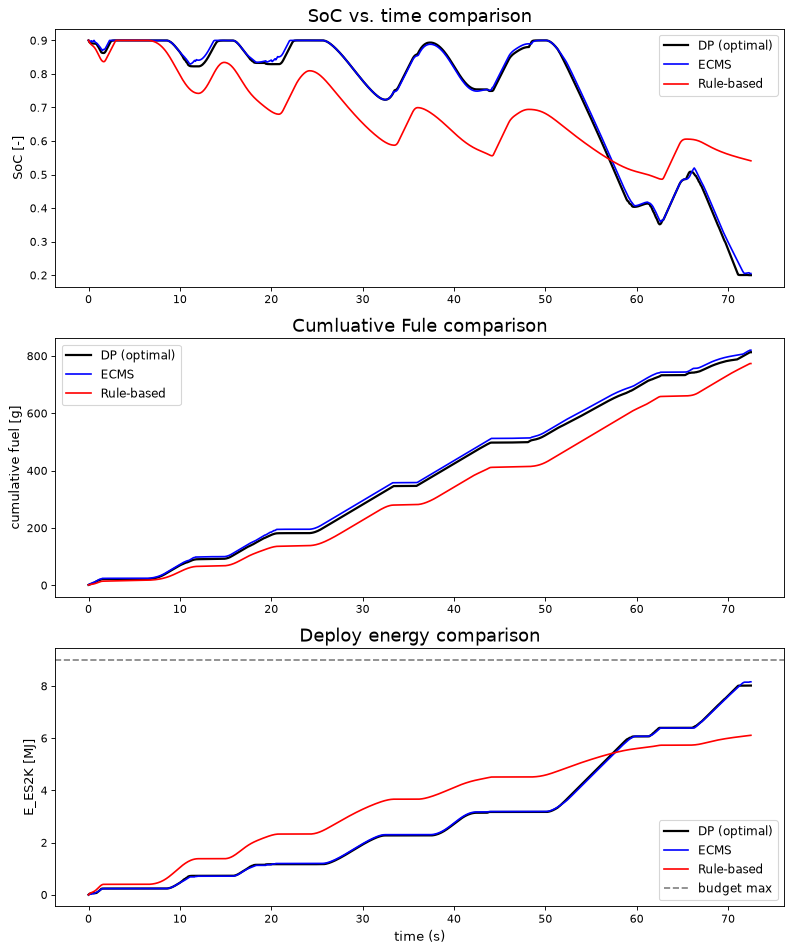

In [7]:
plot.figure(figsize=(10, 12), dpi=80, facecolor='w')

plot.subplot(3,1,1)
plot.plot(t, SoC_dp, 'k', label='DP (optimal)', linewidth=2)
plot.plot(t, SoC_ecms, 'b', label='ECMS')
plot.plot(t, SoC_rb, 'r', label='Rule-based')
plot.ylabel('SoC [-]', fontsize=12)
plot.title('SoC vs. time comparison', fontsize=16)
plot.legend(fontsize=11)

plot.subplot(3,1,2)
plot.plot(t, np.cumsum(J_dp)*1e3, 'k', label='DP (optimal)', linewidth=2)
plot.plot(t, np.cumsum(J_ecms)*1e3, 'b', label='ECMS')
plot.plot(t, np.cumsum(J_rb)*1e3, 'r', label='Rule-based')
plot.ylabel('cumulative fuel [g]', fontsize=12)
plot.title('Cumluative Fule comparison', fontsize=16)
plot.legend(fontsize=11)

plot.subplot(3,1,3)
plot.plot(t, E_ES2K_dp/1e6, 'k', label='DP (optimal)', linewidth=2)
plot.plot(t, E_ES2K_ecms/1e6, 'b', label='ECMS')
plot.plot(t, E_ES2K_rb/1e6, 'r', label='Rule-based')
plot.axhline(E_ES2K_max/1e6, color='gray', linestyle='--', label='budget max')
plot.ylabel('E_ES2K [MJ]', fontsize=12)
plot.xlabel('time (s)', fontsize=12)
plot.title('Deploy energy comparison', fontsize=16)
plot.legend(fontsize=11)

plot.tight_layout()
plot.show()


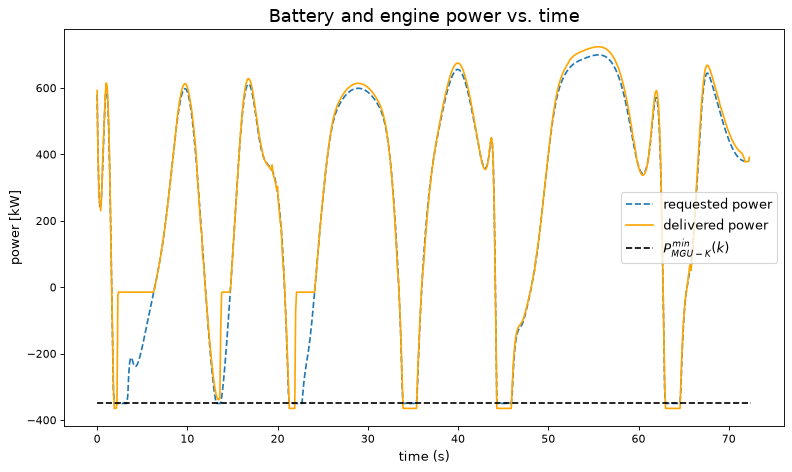

In [8]:
P_gb2 = np.zeros_like(P_gb)
for k in range(len(P_gb)):
    if P_gb[k]<=P_MGU_min:
        P_gb2[k] = P_MGU_min
    else:
        P_gb2[k]=P_gb[k]

plot.figure(num=1, figsize=(10, 6), dpi=80, facecolor='w', edgecolor='k')
plot.subplot(1,1,1)
plot.plot(t[0:-2], (P_gb2[0:-2])/1e3, '--',label='requested power')
plot.plot(t[0:-2], (P_MGUK_ecms[0:-2]+P_eng_ecms[0:-2])/1e3, 'orange', label='delivered power')
plot.plot(t, P_MGU_min*np.ones(t.shape)/1e3, 'k--', label=r'$P_{MGU-K}^{min}(k)$')
plot.ylabel('power [kW]', fontsize=12)
plot.title('Battery and engine power vs. time', fontsize=16)
plot.xlabel('time (s)', fontsize=12)
plot.tight_layout()
plot.legend(loc=0, fontsize=12)

In [9]:
np.savez('data/results/single_lap_comparison.npz',
         t=t, Pgb=P_gb,
         SoC_dp=SoC_dp,     J_dp=J_dp,     E_ES2K_dp=E_ES2K_dp,     shortfall_dp=shortfall_dp,
         SoC_ecms=SoC_ecms, J_ecms=J_ecms, E_ES2K_ecms=E_ES2K_ecms, shortfall_ecms=sf_ecms,
         SoC_rb=SoC_rb,     J_rb=J_rb,     E_ES2K_rb=E_ES2K_rb,     shortfall_rb=shortfall_rb)